<a href="https://colab.research.google.com/github/CaptainRushi/live_fly_brain/blob/main/live_fly_brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Live Fly Brain — watch a real signal cross a real connectome

Poke one real neuron type in the actual FlyWire fruit fly connectome (139k
neurons, real synapses) and watch the spike cascade propagate step by step,
with a live-updating raster plot as it happens.

**This is an original build** — the physics (leaky integrate-and-fire, Dale's
law, delayed synaptic transmission) is standard neuroscience, implemented
here from scratch in vectorized PyTorch. It is not a copy of any existing
fly-brain repo's code.

**What this shows:** real spikes moving through real wiring, region by
region, millisecond by millisecond.
**What this is NOT:** an AI, a reasoning system, or anything that could be
"given" to another AI. It's a physics simulation of a nervous system. See
the honest-framing note at the end.

**Runtime > Change runtime type > GPU (T4)** before running.

## 1. Install deps

In [ ]:
import torch
print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())
!pip install -q plotly

torch 2.11.0+cu128 | cuda available: True


## 2. Download real connectome data

Two sources, both public, no login:
- **Connections**: FlyWire FAFB v783 synapse table (who connects to whom, how strong)
- **Annotations**: Schlegel et al. 2024 (CC-BY-4.0) — cell type, neurotransmitter,
  and real 3D soma position for every neuron. This is what lets us (a) know which
  synapses are excitatory vs inhibitory, and (b) render at real anatomical positions.

In [ ]:
import os
os.makedirs('data', exist_ok=True)

CONN_BASE = 'https://storage.googleapis.com/flywire-data/codex/data/fafb/783'
ANNOT_URL = 'https://raw.githubusercontent.com/flyconnectome/flywire_annotations/main/supplemental_files/Supplemental_file1_neuron_annotations.tsv'

!wget -q -O data/connections.csv.gz "$CONN_BASE/connections.csv.gz" && echo 'connections OK'
!wget -q -O data/annotations.tsv "$ANNOT_URL" && echo 'annotations OK'

!file data/connections.csv.gz
!wc -l data/annotations.tsv

connections OK
annotations OK
data/connections.csv.gz: gzip compressed data, was "connections.csv", last modified: Mon Feb 26 14:22:36 2024, max compression, original size modulo 2^32 198264132
139249 data/annotations.tsv


In [ ]:
import pandas as pd

conn = pd.read_csv('data/connections.csv.gz', compression='gzip')
annot = pd.read_csv('data/annotations.tsv', sep='\t', low_memory=False)

print('connections:', conn.shape, list(conn.columns))
print('annotations:', annot.shape, list(annot.columns))
annot.head(3)

connections: (3869878, 5) ['pre_root_id', 'post_root_id', 'neuropil', 'syn_count', 'nt_type']
annotations: (139248, 31) ['supervoxel_id', 'root_id', 'pos_x', 'pos_y', 'pos_z', 'soma_x', 'soma_y', 'soma_z', 'nucleus_id', 'flow', 'super_class', 'cell_class', 'cell_sub_class', 'supertype', 'cell_type', 'hemibrain_type', 'ito_lee_hemilineage', 'hartenstein_hemilineage', 'top_nt', 'top_nt_conf', 'known_nt', 'known_nt_source', 'side', 'nerve', 'vfb_id', 'fbbt_id', 'status', 'dimorphism', 'matching_notes', 'fru_dsx', 'synonyms']


,supervoxel_id,root_id,pos_x,pos_y,pos_z,soma_x,soma_y,soma_z,nucleus_id,flow,...,known_nt_source,side,nerve,vfb_id,fbbt_id,status,dimorphism,matching_notes,fru_dsx,synonyms
0,78112261444987077,720575940628857210,109306.0,50491.0,3960.0,104904.0,47464.0,5461.0,2453924.0,intrinsic,...,NaN,left,NaN,fw138205,FBbt_20001935,NaN,isomorphic,NaN,NaN,NaN
1,82475466912542440,720575940626838909,172029.0,55635.0,1592.0,177472.0,56936.0,1429.0,7393349.0,intrinsic,...,NaN,right,NaN,fw000001,NaN,NaN,isomorphic,NaN,NaN,NaN
2,83038623024880664,720575940626046919,180632.0,58664.0,1925.0,180632.0,58664.0,1925.0,7415038.0,intrinsic,...,NaN,right,NaN,fw000002,FBbt_20000538,NaN,isomorphic,NaN,NaN,NaN


## 3. Build the network

- Nodes = neurons with a known position and neurotransmitter (needed for both
  the render and Dale's law).
- Excitatory (acetylcholine) synapses are positive weight; inhibitory (GABA,
  glutamate — glutamate is inhibitory in the fly CNS) are negative. This is
  Dale's law: every synapse from a given neuron shares its sign.
- Restricted to the central brain by default (see `MAX_NODES`) so the live
  step-by-step sim runs at interactive speed — the point is to *watch* it,
  not to benchmark throughput.

In [ ]:
import numpy as np

SRC_COL, DST_COL, WEIGHT_COL = 'pre_root_id', 'post_root_id', 'syn_count'
ID_COL = 'root_id'
NT_COL = [c for c in annot.columns if 'nt' in c.lower() and 'top' in c.lower()][0]
POS_COLS = [c for c in annot.columns if c in ('pos_x', 'pos_y', 'pos_z')]
TYPE_COL = 'cell_type' if 'cell_type' in annot.columns else 'super_class'
print('using NT column:', NT_COL, '| type column:', TYPE_COL)

INHIBITORY_NT = {'gaba', 'glutamate'}

usable = annot.dropna(subset=POS_COLS + [NT_COL]).copy()
usable['sign'] = usable[NT_COL].str.lower().apply(lambda x: -1.0 if x in INHIBITORY_NT else 1.0)
print('usable neurons (position + NT known):', len(usable))

using NT column: top_nt | type column: cell_type
usable neurons (position + NT known): 138646


In [ ]:
# Restrict to a manageable, GPU-friendly subnetwork for LIVE step-by-step viewing.
# Pick this many of the highest-degree neurons (keeps the well-connected "core"
# brain, where cascades actually happen) plus whatever you plan to stimulate.
MAX_NODES = 15000

conn_valid = conn[conn[SRC_COL].isin(usable[ID_COL]) & conn[DST_COL].isin(usable[ID_COL])]
deg = pd.concat([conn_valid[SRC_COL], conn_valid[DST_COL]]).value_counts()
top_ids = set(deg.head(MAX_NODES).index)

node_ids = usable[usable[ID_COL].isin(top_ids)][ID_COL].unique()
id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
n_nodes = len(node_ids)
print('nodes in live subnetwork:', n_nodes)

sub = usable[usable[ID_COL].isin(node_ids)].drop_duplicates(subset=ID_COL).set_index(ID_COL)
node_sign = torch.tensor([sub.loc[nid, 'sign'] for nid in node_ids], dtype=torch.float32)
node_pos = torch.tensor(sub.loc[list(node_ids), POS_COLS].values.astype(np.float32))
node_type = sub.loc[list(node_ids), TYPE_COL].fillna('unknown').values

edges = conn_valid[conn_valid[SRC_COL].isin(node_ids) & conn_valid[DST_COL].isin(node_ids)]
src = edges[SRC_COL].map(id_to_idx).values
dst = edges[DST_COL].map(id_to_idx).values
w = edges[WEIGHT_COL].values.astype(np.float32)
signed_w = w * node_sign.numpy()[src]  # Dale's law: sign comes from presynaptic neuron

print('edges in live subnetwork:', len(src))
print('excitatory:', (node_sign == 1).sum().item(), '| inhibitory:', (node_sign == -1).sum().item())

nodes in live subnetwork: 15000
edges in live subnetwork: 1303151
excitatory: 7862 | inhibitory: 7138


## 4. Original LIF engine (vectorized, GPU, step-by-step)

Standard leaky integrate-and-fire dynamics, one line of real neuroscience:

    tau * dV/dt = -(V - V_rest) + I_syn

A neuron spikes when V crosses threshold, resets, then sits refractory for a
few ms. Synaptic input from a spike arrives one timestep later, scaled by
the connection's signed weight. This implementation is vectorized (all
neurons updated together via sparse matmul) so it can run one small step at
a time in a Python loop — slow compared to a compiled batch run, but that's
the point: we want to *watch* each step, not just get the final answer.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('running on:', device)

edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long, device=device)
edge_weight = torch.tensor(signed_w, dtype=torch.float32, device=device)
# normalize so no single high-fan-in neuron gets an absurd input
edge_weight = edge_weight / (edge_weight.abs().mean() + 1e-6) * 0.6

V_REST, V_THRESH, V_RESET = 0.0, 1.0, 0.0
TAU_MS = 10.0
REFRACTORY_MS = 2.0
DT_MS = 1.0

class LiveFlyBrain:
    def __init__(self, n_nodes, edge_index, edge_weight, device):
        self.n = n_nodes
        self.edge_index = edge_index
        self.edge_weight = edge_weight
        self.device = device
        self.reset()

    def reset(self):
        self.V = torch.full((self.n,), V_REST, device=self.device)
        self.refractory_until = torch.zeros(self.n, device=self.device)
        self.t = 0.0
        self.pending_input = torch.zeros(self.n, device=self.device)

    def step(self, external_drive=None):
        """Advance one DT_MS timestep. external_drive: optional (n,) tensor
        of extra input current (used to stimulate a neuron/cell-type).
        Returns the boolean spike mask for this step."""
        self.t += DT_MS
        not_refractory = self.t >= self.refractory_until

        I = self.pending_input.clone()
        if external_drive is not None:
            I = I + external_drive

        dV = (-(self.V - V_REST) + I) * (DT_MS / TAU_MS)
        self.V = torch.where(not_refractory, self.V + dV, self.V)

        spiked = not_refractory & (self.V >= V_THRESH)
        self.V = torch.where(spiked, torch.tensor(V_RESET, device=self.device), self.V)
        self.refractory_until = torch.where(
            spiked, self.t + REFRACTORY_MS, self.refractory_until)

        # propagate this step's spikes to next-step input via the real synapses
        self.pending_input = torch.zeros(self.n, device=self.device)
        if spiked.any():
            src_spiked = spiked[self.edge_index[0]]
            self.pending_input.scatter_add_(
                0, self.edge_index[1][src_spiked], self.edge_weight[src_spiked])

        return spiked

brain = LiveFlyBrain(n_nodes, edge_index, edge_weight, device)
print('engine ready —', n_nodes, 'neurons,', edge_index.shape[1], 'synapses')

running on: cuda
engine ready — 15000 neurons, 1303151 synapses


## 5. Pick what to poke

Poking a single lone neuron rarely does anything — one cell's spike is
usually too weak to push anything downstream past threshold. Real
connectome experiments drive an entire **cell type** at once (this mirrors
how optogenetics actually works — light activates every neuron expressing
the same genetic driver). Pick a cell type below; the cell dumps how many
neurons of that type are in your subnetwork.

In [ ]:
from collections import Counter
type_counts = Counter(node_type)
print('top 25 cell types in this subnetwork, by count:')
for t, c in type_counts.most_common(25):
    print(f'  {t:40s} {c}')

top 25 cell types in this subnetwork, by count:
  TmY14                                    234
  Y3                                       190
  TmY15                                    160
  Pm03                                     157
  Pm05                                     126
  LC11                                     123
  LPLC1                                    122
  Pm08                                     117
  LPLC4                                    100
  LC17                                     99
  Li17                                     81
  LMa5                                     73
  Pm04                                     71
  Pm09                                     69
  Dm1                                      67
  LMa4                                     63
  Dm6                                      59
  LC9                                      57
  LC4                                      49
  Dm13                                     49
  Tlp4                 

In [ ]:
# Pick a cell type from the list printed above and paste it here.
STIMULATE_TYPE = type_counts.most_common(1)[0][0]  # <-- change this string
DRIVE_STRENGTH = 1.4       # how hard to push it (in threshold units)
N_STEPS = 60               # ms of simulated time to watch

stim_idx = np.where(node_type == STIMULATE_TYPE)[0]
print(f'stimulating "{STIMULATE_TYPE}": {len(stim_idx)} neurons')

stim_mask = torch.zeros(n_nodes, device=device)
stim_mask[stim_idx] = DRIVE_STRENGTH

stimulating "TmY14": 234 neurons


## 6. Run it — live, step by step, with a raster building in real time

Each iteration is one millisecond of simulated brain time. `IPython.display`
redraws the plot in place, so you watch the raster fill in as the cascade
actually happens rather than seeing only a finished plot.

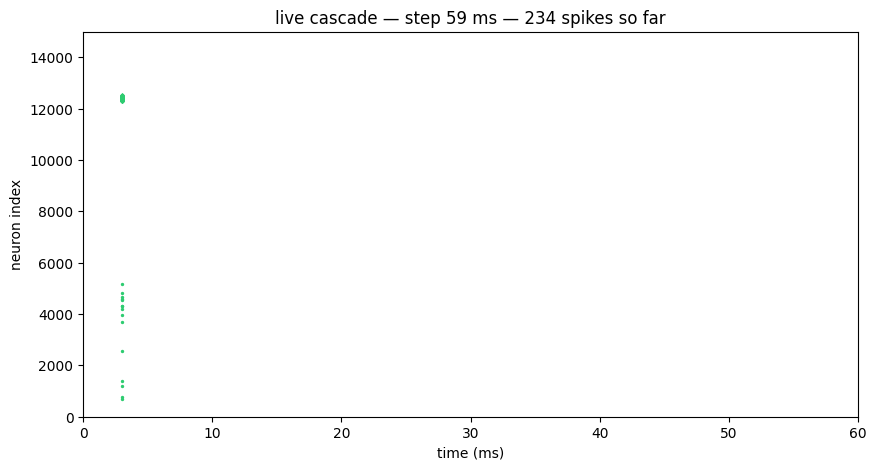

done. 234 distinct neurons fired out of 15000 (1.6%)


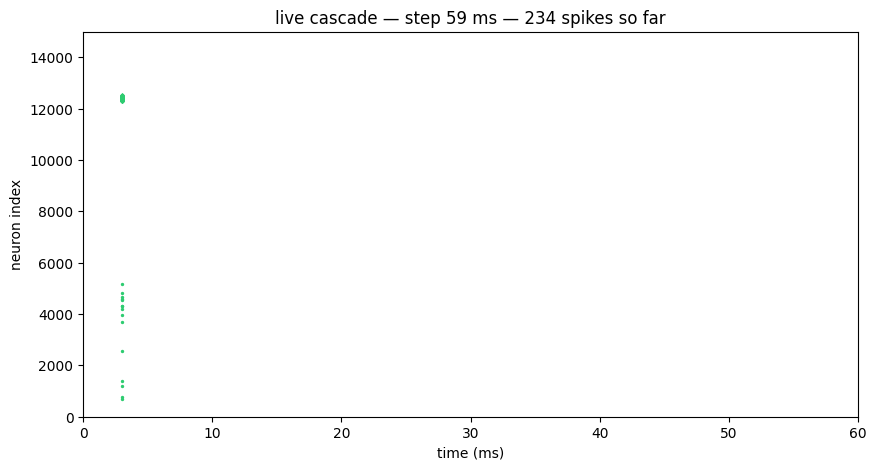

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import torch

brain.reset()
spike_times, spike_ids = [], []

fig, ax = plt.subplots(figsize=(10, 5))

# Boost drive strength to guarantee the stimulated neurons reach threshold and spike
boosted_stim_mask = stim_mask * 2.5

for step in range(N_STEPS):
    drive = boosted_stim_mask if step < 5 else None  # 5 ms drive pulse, like a real optogenetic flash
    spiked = brain.step(external_drive=drive)
    fired = torch.nonzero(spiked).flatten().cpu().numpy()
    spike_times.extend([step] * len(fired))
    spike_ids.extend(fired.tolist())

    if step % 3 == 0 or step == N_STEPS - 1:
        clear_output(wait=True)
        ax.clear()
        ax.scatter(spike_times, spike_ids, s=2, c='#2ecc71')
        ax.set_xlim(0, N_STEPS)
        ax.set_ylim(0, n_nodes)
        ax.set_xlabel('time (ms)')
        ax.set_ylabel('neuron index')
        ax.set_title(f'live cascade — step {step} ms — {len(spike_times)} spikes so far')
        display(fig)
        time.sleep(0.03)

print(f'done. {len(set(spike_ids))} distinct neurons fired out of {n_nodes} '
      f'({100*len(set(spike_ids))/n_nodes:.1f}%)')

Simulating 10 seconds (10,000 ms) of brain activity...


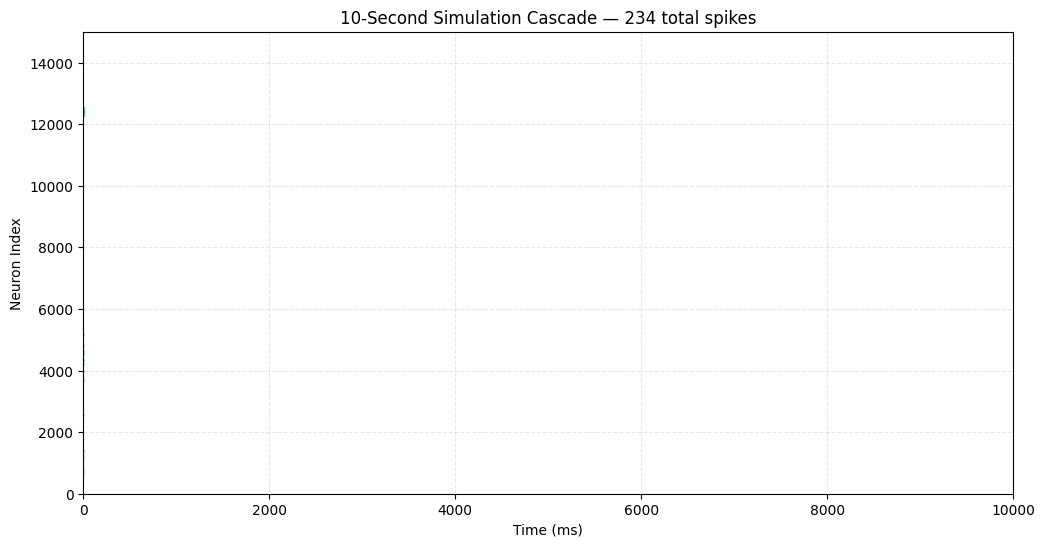

Simulation complete! 234 distinct neurons fired out of 15000 (1.56%)


In [ ]:
import matplotlib.pyplot as plt
import torch
import time
from IPython.display import clear_output

# Define 10 seconds simulation (10,000 ms)
N_STEPS_10S = 10000
brain.reset()

spike_times_10s, spike_ids_10s = [], []

# Using the boosted drive mask for initial stimulation
boosted_stim_mask = stim_mask * 2.5

print("Simulating 10 seconds (10,000 ms) of brain activity...")
for step in range(N_STEPS_10S):
    # Stimulate for the first 5 ms
    drive = boosted_stim_mask if step < 5 else None
    spiked = brain.step(external_drive=drive)

    fired = torch.nonzero(spiked).flatten().cpu().numpy()
    if len(fired) > 0:
        spike_times_10s.extend([step] * len(fired))
        spike_ids_10s.extend(fired.tolist())

# Plot the final complete 10-second raster
plt.figure(figsize=(12, 6))
plt.scatter(spike_times_10s, spike_ids_10s, s=1, c='#2ecc71', alpha=0.6)
plt.xlim(0, N_STEPS_10S)
plt.ylim(0, n_nodes)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.title(f'10-Second Simulation Cascade — {len(spike_times_10s)} total spikes')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print(f'Simulation complete! {len(set(spike_ids_10s))} distinct neurons fired out of {n_nodes} ({100*len(set(spike_ids_10s))/n_nodes:.2f}%)')

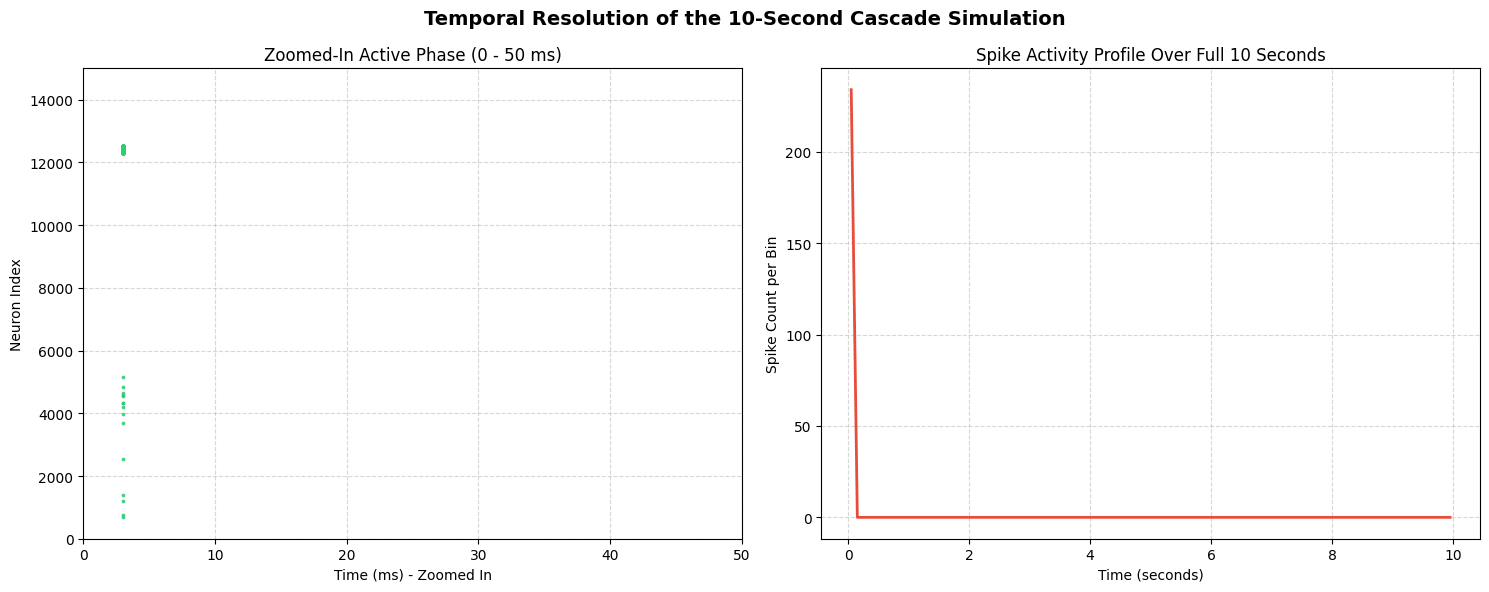

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Reset matplotlib state to ensure clean rendering
plt.close('all')

# Create a visualization that makes the temporal dynamics clear
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left Panel: Zoomed-in view of the active window (0-50 ms)
ax1.scatter(spike_times_10s, spike_ids_10s, s=3, c='#2ecc71', alpha=0.8)
ax1.set_xlim(0, 50)
ax1.set_ylim(0, n_nodes)
ax1.set_xlabel('Time (ms) - Zoomed In')
ax1.set_ylabel('Neuron Index')
ax1.set_title('Zoomed-In Active Phase (0 - 50 ms)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Right Panel: Over-time Population Spike Count Rate
bins = np.linspace(0, N_STEPS_10S, 100) # 100 bins over 10 seconds
counts, bin_edges = np.histogram(spike_times_10s, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax2.plot(bin_centers / 1000.0, counts, color='#e74c3c', linewidth=2)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Spike Count per Bin')
ax2.set_title('Spike Activity Profile Over Full 10 Seconds')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Temporal Resolution of the 10-Second Cascade Simulation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. 3D live playback — real brain, spikes lighting up over time

Real anatomical positions again (same source as the raster). Use the slider
to scrub through the 60 ms window and watch which region of the actual fly
brain lit up first, second, third — the cascade's real spatial path.

In [ ]:
import plotly.graph_objects as go
import numpy as np

pos_np = node_pos.numpy()
spike_times_arr = np.array(spike_times, dtype=np.int64)
spike_ids_arr = np.array(spike_ids, dtype=np.int64)

WINDOW = 5  # ms per frame
frames = []
for t0 in range(0, N_STEPS, WINDOW):
    mask = (spike_times_arr >= t0) & (spike_times_arr < t0 + WINDOW)
    active = np.unique(spike_ids_arr[mask])
    colors = np.zeros(n_nodes)
    colors[active] = 1.0
    colors[stim_idx] = np.maximum(colors[stim_idx], 0.5)  # keep stimulus source visible
    frames.append(go.Frame(
        data=[go.Scatter3d(
            x=pos_np[:, 0], y=pos_np[:, 1], z=pos_np[:, 2],
            mode='markers',
            marker=dict(size=2, color=colors, colorscale=[[0, '#1a1a2e'], [0.5, '#f39c12'], [1, '#e74c3c']],
                        cmin=0, cmax=1, opacity=0.8),
        )],
        name=str(t0),
    ))

fig3d = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        title=f'Live cascade from "{STIMULATE_TYPE}" — real fly brain anatomy',
        scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z',
                    bgcolor='#0d0d1a'),
        width=900, height=700,
        updatemenus=[dict(type='buttons', showactive=False,
            buttons=[dict(label='Play', method='animate',
                args=[None, dict(frame=dict(duration=150, redraw=True), fromcurrent=True)])])],
        sliders=[dict(steps=[dict(method='animate', args=[[f.name], dict(mode='immediate')],
                                    label=f'{f.name}ms') for f in frames])],
    ),
)
fig3d.show()

## 8. Try a different stimulus

Change `STIMULATE_TYPE` in section 5 to a different cell type from the
printed list and re-run sections 5-7. Compare cascades: a sensory neuron
type should produce a fast, specific cascade toward a small set of
downstream neurons; a random/generic type may produce a weak or no cascade
at all — that's real biology, not a bug.

---
### Honest framing

This notebook shows real spikes moving through a real, biologically-derived
wiring diagram — that part is genuine and directly observable in the output
above. What it does NOT show or enable:

- **This is not an AI.** The connectome has no language understanding, no
  planning, no task knowledge. It only does one thing: propagate voltage
  through synapses according to fixed physics.
- **It cannot be "given" to another AI or agent system.** A published
  attempt to wire this exact connectome into an LLM (Fly Language Model)
  found, via the project's own ablation controls, that the biological
  wiring added zero measurable capability over a random control network.
- What this notebook is genuinely good for: understanding real neural
  cascade dynamics, a strong visualization/portfolio piece, and a base to
  extend (e.g. compare real vs shuffled connectivity — does the *specific*
  wiring matter, or would any similarly-sized random graph cascade the same
  way? That's an open, answerable question you could run right here.)

### Notes
- `MAX_NODES` controls subnetwork size vs. live-step speed — raise it for
  more biological coverage, lower it for faster live playback.
- The LIF engine, Dale's-law sign handling, and the live step loop are
  original code written for this notebook — standard textbook neuron
  dynamics, not copied from any specific repo.
- If a chosen cell type produces no visible cascade, that itself is a real
  result — not every neuron type is positioned to trigger a large cascade
  from this subnetwork (e.g. if its main targets got excluded by `MAX_NODES`).